## Problem statement
```bash
Linear Regression models the relationship between an independent variable X and a dependent variable y using the equation:
y = wX + b
where w is the weight (slope) and b is the bias (intercept).
The goal of training is to learn the values of w and b that minimize the error between predicted and actual values, using Gradient Descent and the Mean Squared Error (MSE) loss function:
Loss = (1/n) Σ (y_actual − y_predicted)²
The gradients of the loss with respect to w and b are computed and used to iteratively update the parameters:
w = w − lr × ∂Loss/∂w
b = b − lr × ∂Loss/∂b
This lab is divided into two parts:
•
Part A: Manual implementation of Linear Regression using NumPy (gradients derived and coded by hand).
•
Part B: Implementation of the same problem using PyTorch's nn.Module, autograd, and optimizer. Purwanchal
```

In [2]:
import torch
import numpy as np
from sklearn.model_selection import train_test_split
print(torch.__version__)
print(torch.version.cuda)
print(torch.cuda.is_available())

2.6.0+cu124
12.4
True


In [3]:
import torch

print("PyTorch:", torch.__version__)
print("CUDA Runtime:", torch.version.cuda)
print("CUDA Available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

PyTorch: 2.6.0+cu124
CUDA Runtime: 12.4
CUDA Available: True
GPU: NVIDIA GeForce RTX 3050 6GB Laptop GPU


In [4]:
import torch

In [5]:
device = None
if torch.cuda.is_available():
    device = 'cuda'
elif torch.backends.mps.is_available():
    device = 'mps'
else:
    device = 'cpu'
print(device)

cuda


In [6]:
m = 0.1234
c = 0.6789
X = np.arange(0,2,0.04)
y = m*X + c

split = int(0.8*len(X))

X_train, y_train = X[:split], y[:split]
X_test, y_test = X[split:], y[split:]

X_train_tensors = torch.from_numpy(X_train)
y_train_tensors = torch.from_numpy(y_train)
X_test_tensors = torch.from_numpy(X_test)
y_test_tensors = torch.from_numpy(y_test)
print(f"Shape of the X_train is {X_train.shape} and type is {type(X_train)}")
print(f"Shape of X_train_tensor is {X_train_tensors.shape} and type is {type(X_train_tensors)}")

Shape of the X_train is (40,) and type is <class 'numpy.ndarray'>
Shape of X_train_tensor is torch.Size([40]) and type is <class 'torch.Tensor'>


In [7]:
import matplotlib.pyplot as plt
def plot_data(
    X_train=X_train_tensors, y_train = y_train_tensors, X_test = X_test_tensors, y_test = y_test_tensors,
    predictions = None):

    plt.scatter(X_train, y_train, c='b', label= 'Training Data')
    plt.scatter(X_test, y_test, c="r", label='Testing Data')
    if predictions is not None:
        plt.plot(X_test, predictions, c='g', label='Predictions')
    plt.xlabel('X')
    plt.ylabel('y')
    plt.title(' X vs y')
    plt.legend()
    plt.show()


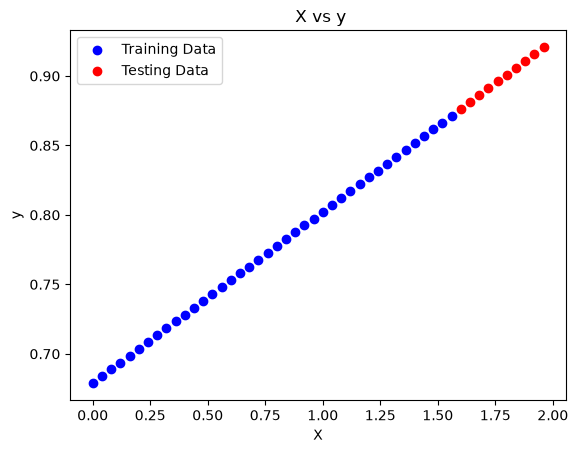

In [8]:
plot_data()

In [9]:
import torch
import torch.nn as nn

class MyFirstNeuralNetwork(nn.Module):
    def __init__(self):
        super().__init__()
        # Use nn.Parameter instead of nn.parameter
        self.weights = nn.Parameter(torch.randn(1, requires_grad=True, dtype=torch.float))
        self.bias = nn.Parameter(torch.randn(1, requires_grad=True, dtype=torch.float))

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.weights * x + self.bias   # usually linear form: w*x + b

In [10]:
torch.manual_seed(42)
model = MyFirstNeuralNetwork()
print(model.state_dict())

OrderedDict([('weights', tensor([0.3367])), ('bias', tensor([0.1288]))])
